In [1]:
import control as ct

In [2]:
s =ct.tf('s')

In [5]:
L=(2.5+2.66)*1E-3
R=2*0.01
Tf=L/R
Fs=10E3
Ts=1/Fs
print('L=',L,'R=',R)
print('Ts=',Ts)

L= 0.0051600000000000005 R= 0.02
Ts= 0.0001


In [7]:
G1=1/(L*s+R)
print(G1)

<TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ----------------
  0.00516 s + 0.02


In [8]:
D=1/(1+1.5*Ts*s)
print(D)

<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        1
  -------------
  0.00015 s + 1


In [9]:
plant=G1*D
print(plant)

<TransferFunction>: sys[18]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                 1
  --------------------------------
  7.74e-07 s^2 + 0.005163 s + 0.02


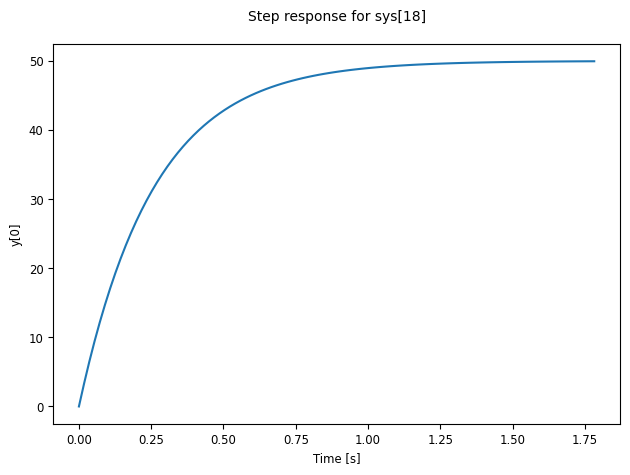

In [10]:
response = ct.step_response(plant)
cplt = response.plot()

In [11]:
Kp=L/(3*Ts)
print('Kp=',Kp)

Kp= 17.2


In [12]:
Ki=Kp/Tf
print('Ki=',Ki)

Ki= 66.66666666666666


In [13]:
PI=Kp+Ki/s
print(PI)

<TransferFunction>: sys[24]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  17.2 s + 66.67
  --------------
        s


In [14]:
Gopen=PI*plant
print(Gopen)

<TransferFunction>: sys[25]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             17.2 s + 66.67
  ------------------------------------
  7.74e-07 s^3 + 0.005163 s^2 + 0.02 s


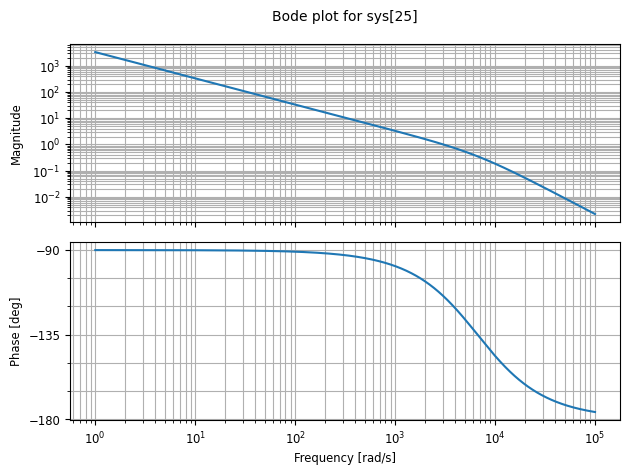

In [15]:
freqresp = ct.frequency_response(Gopen)
cplt = freqresp.plot()

In [16]:
G=Gopen/(1+Gopen)
print(G)

<TransferFunction>: sys[29]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                1.331e-05 s^4 + 0.08886 s^3 + 0.6882 s^2 + 1.333 s
  ------------------------------------------------------------------------------
  5.991e-13 s^6 + 7.992e-09 s^5 + 4e-05 s^4 + 0.08906 s^3 + 0.6886 s^2 + 1.333 s


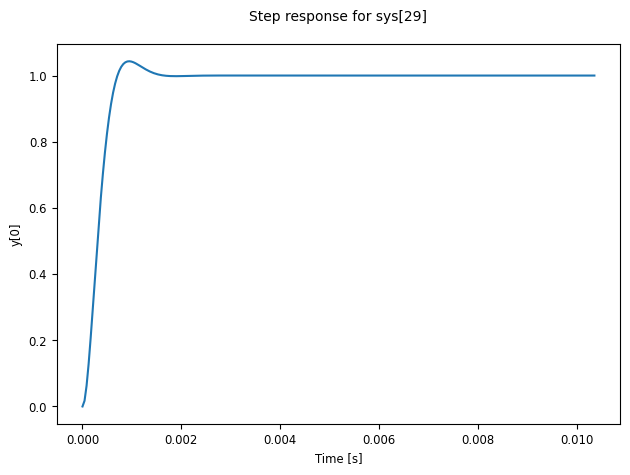

In [17]:
response = ct.step_response(G)
cplt = response.plot()

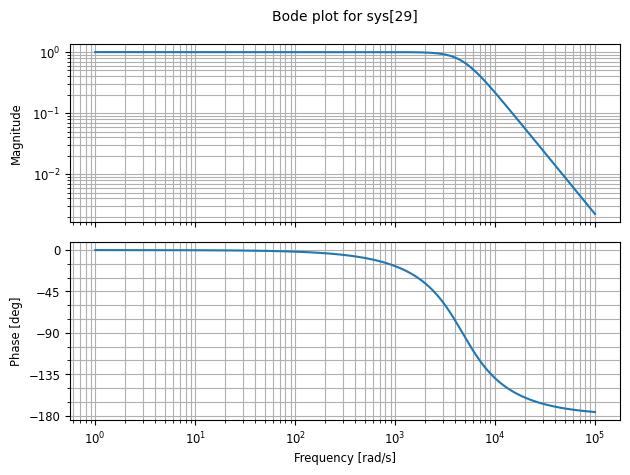

In [18]:
freqresp = ct.frequency_response(G)
cplt = freqresp.plot()